# Comprehensive Linear Regression Analysis for Continuous Outcome Prediction
### Dataset: Auto MPG (Fuel Efficiency of Vehicles)

**Goal:** Build, analyze, and compare a Simple Linear Regression (SLR) model and a
Multiple Linear Regression (MLR) model to predict a car's fuel efficiency (`mpg`),
evaluating both with statistical and visual techniques.

**Source:** UCI Auto MPG dataset (via seaborn-data repository).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42  # for reproducibility of train/test splits only


## 1. Data Understanding

The dataset contains technical specifications of cars from the 1970s-1980s and their
fuel consumption in miles per gallon.

- **Target variable (continuous):** `mpg` — fuel efficiency
- **Numerical features:** `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`
- **Categorical features:** `origin` (usa / europe / japan). `name` is a free-text
  identifier (car model) and is dropped from modeling — it is not a usable feature.


In [2]:
df = pd.read_csv("auto_mpg_raw.csv")
print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Duplicate rows: 0


## 2. Data Cleaning

Issues found in the raw data:
- `horsepower` has 6 missing values and is stored correctly as numeric, but we verify its type.
- Need to check for unrealistic values (e.g. `mpg` <= 0, `cylinders` <= 0).
- Need to check for outliers using the IQR method.
- `name` is dropped (not a modeling feature, just an identifier).


In [5]:
df_clean = df.copy()

# 2.1 Convert / verify data types
df_clean["origin"] = df_clean["origin"].astype("category")
df_clean["cylinders"] = df_clean["cylinders"].astype(int)
df_clean["model_year"] = df_clean["model_year"].astype(int)

# 2.2 Handle missing values: impute horsepower using the median within the same
# cylinder group (cars with the same cylinder count have similar horsepower ranges)
df_clean["horsepower"] = df_clean.groupby("cylinders")["horsepower"].transform(
    lambda s: s.fillna(s.median())
)
print("Remaining missing values:", df_clean.isna().sum().sum())

# 2.3 Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {before - len(df_clean)}")

# 2.4 Handle invalid / unrealistic values
invalid_mask = (df_clean["mpg"] <= 0) | (df_clean["cylinders"] <= 0) | (df_clean["horsepower"] <= 0)
print("Invalid rows found:", invalid_mask.sum())
df_clean = df_clean[~invalid_mask]

# 2.5 Drop non-modeling identifier column
df_clean = df_clean.drop(columns=["name"])
df_clean.reset_index(drop=True, inplace=True)
df_clean.describe()


Remaining missing values: 0
Duplicates removed: 0
Invalid rows found: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.125628,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.313624,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,92.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [6]:
# 2.6 Outlier detection & removal using the IQR method on numeric columns
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_mask = pd.Series(False, index=df_clean.index)
for col in numeric_cols:
    low, high = iqr_bounds(df_clean[col])
    col_outliers = (df_clean[col] < low) | (df_clean[col] > high)
    print(f"{col}: {col_outliers.sum()} outliers (bounds: {low:.2f} - {high:.2f})")
    outlier_mask |= col_outliers

print(f"\nTotal rows flagged as outliers (any column): {outlier_mask.sum()} out of {len(df_clean)}")
df_clean = df_clean[~outlier_mask].reset_index(drop=True)
print("Final cleaned shape:", df_clean.shape)


mpg: 1 outliers (bounds: 0.25 - 46.25)
cylinders: 0 outliers (bounds: -2.00 - 14.00)
displacement: 0 outliers (bounds: -132.38 - 498.62)
horsepower: 11 outliers (bounds: 2.50 - 198.50)
weight: 0 outliers (bounds: 147.38 - 5684.38)
acceleration: 7 outliers (bounds: 8.80 - 22.20)

Total rows flagged as outliers (any column): 18 out of 398
Final cleaned shape: (380, 8)


## 3. Exploratory Data Analysis (EDA)

In [7]:
df_clean.describe(include="all")


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usa
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,236
mean,23.701579,5.386842,187.446053,101.089474,2933.168421,15.638421,76.152632,NaN
std,7.509740,1.666157,98.133984,33.153873,822.759728,2.488570,3.617295,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,9.500000,70.000000,NaN
25%,18.000000,4.000000,103.250000,76.000000,2219.750000,14.000000,73.000000,NaN
50%,23.000000,4.000000,144.500000,92.000000,2764.500000,15.500000,76.000000,NaN
75%,29.000000,6.000000,258.000000,115.000000,3521.250000,17.125000,79.000000,NaN


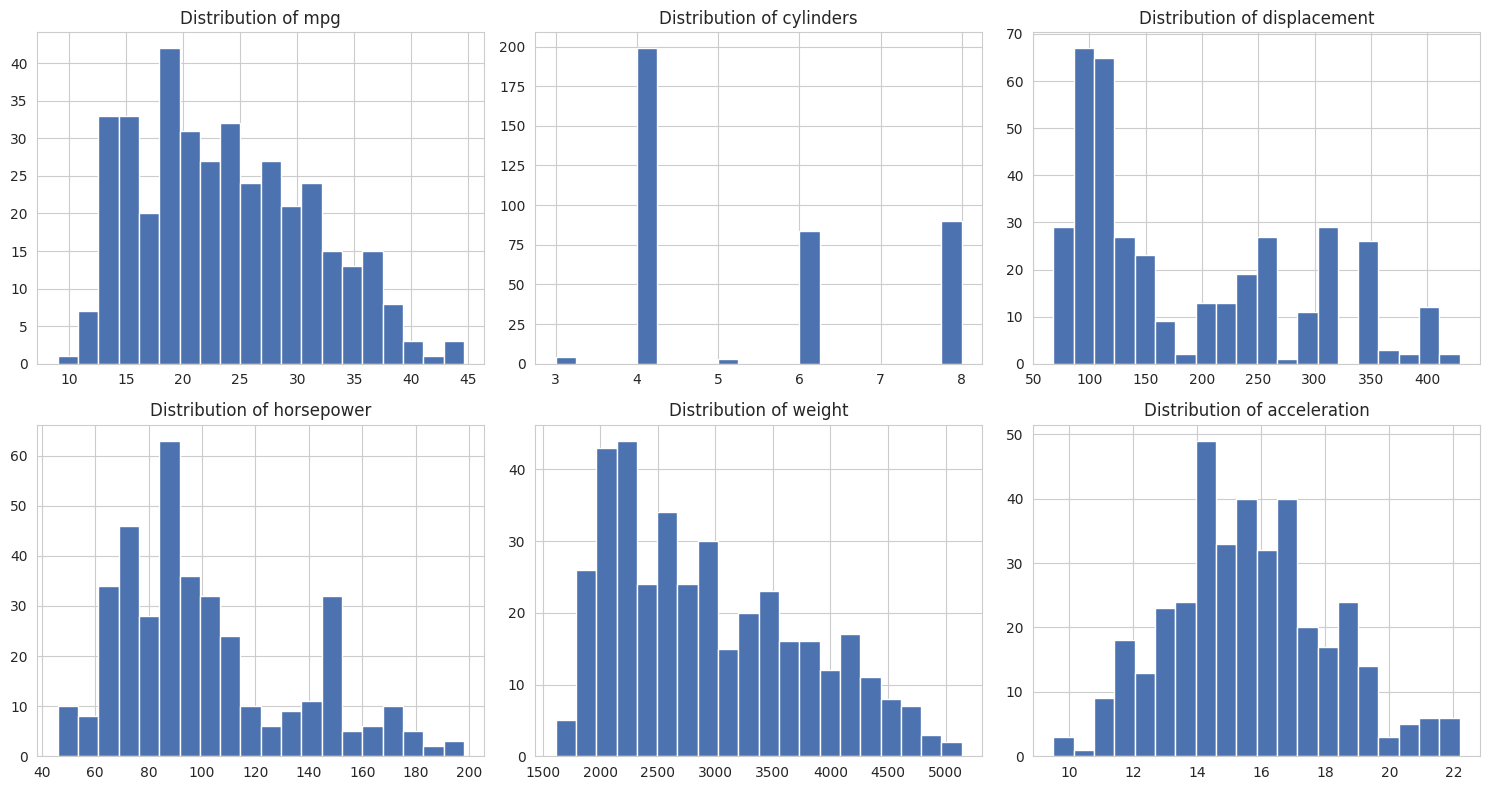

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df_clean[col], bins=20, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("hist_grid.png", dpi=110)
plt.show()


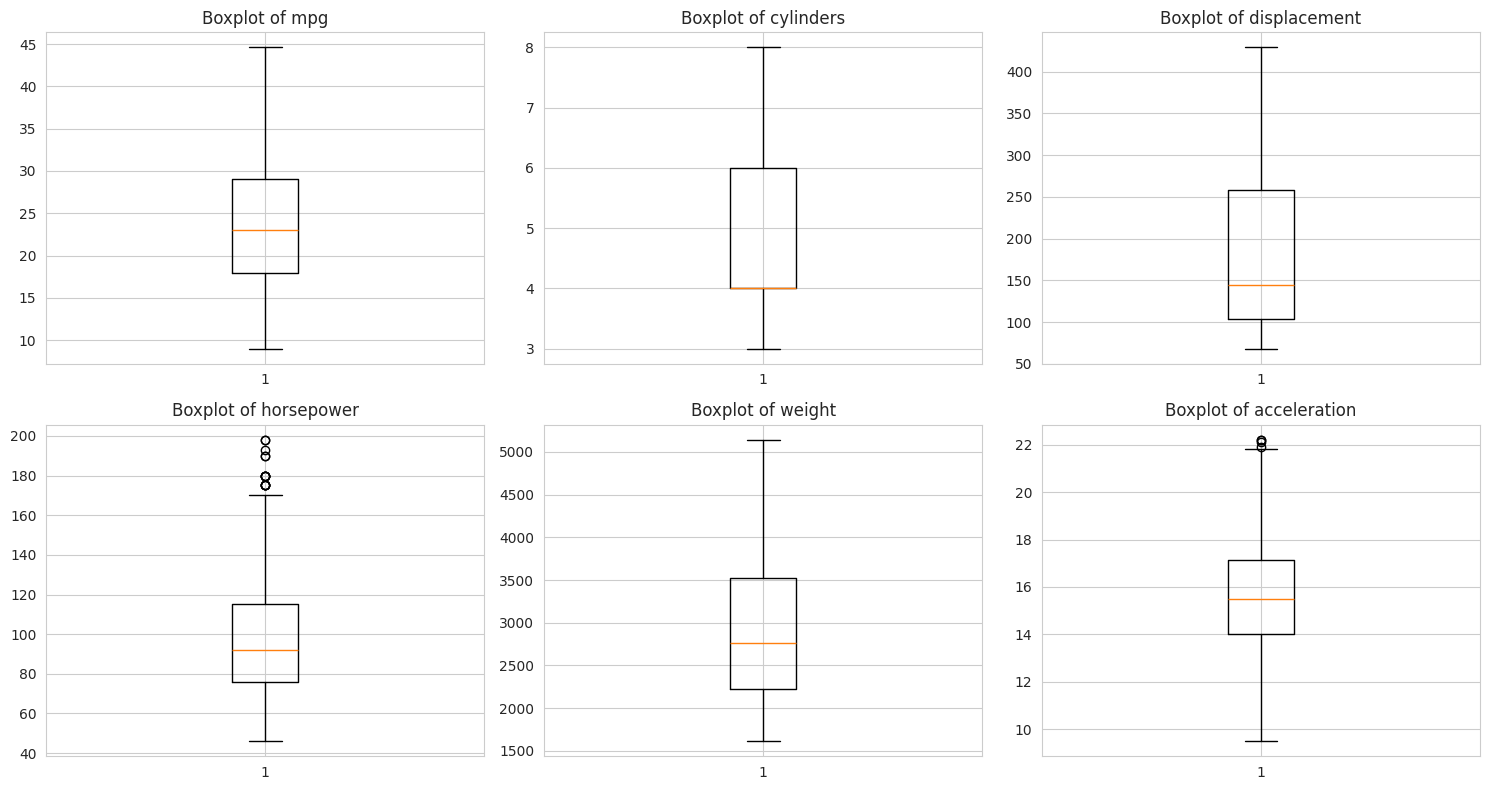

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df_clean[col], vert=True)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig("boxplot_grid.png", dpi=110)
plt.show()


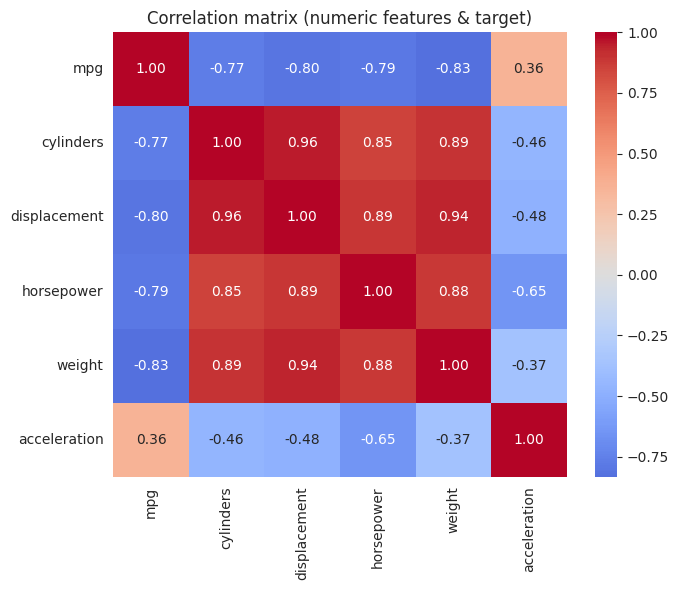

Correlation of each feature with mpg (sorted by strength):
weight         -0.832321
displacement   -0.804821
horsepower     -0.785950
cylinders      -0.767667
acceleration    0.357882
Name: mpg, dtype: float64

Strongest single predictor of mpg: 'weight' (r = -0.832)


In [10]:
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features & target)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=110)
plt.show()

target_corr = corr["mpg"].drop("mpg").sort_values(key=abs, ascending=False)
print("Correlation of each feature with mpg (sorted by strength):")
print(target_corr)
best_feature = target_corr.abs().idxmax()
print(f"\nStrongest single predictor of mpg: '{best_feature}' (r = {target_corr[best_feature]:.3f})")


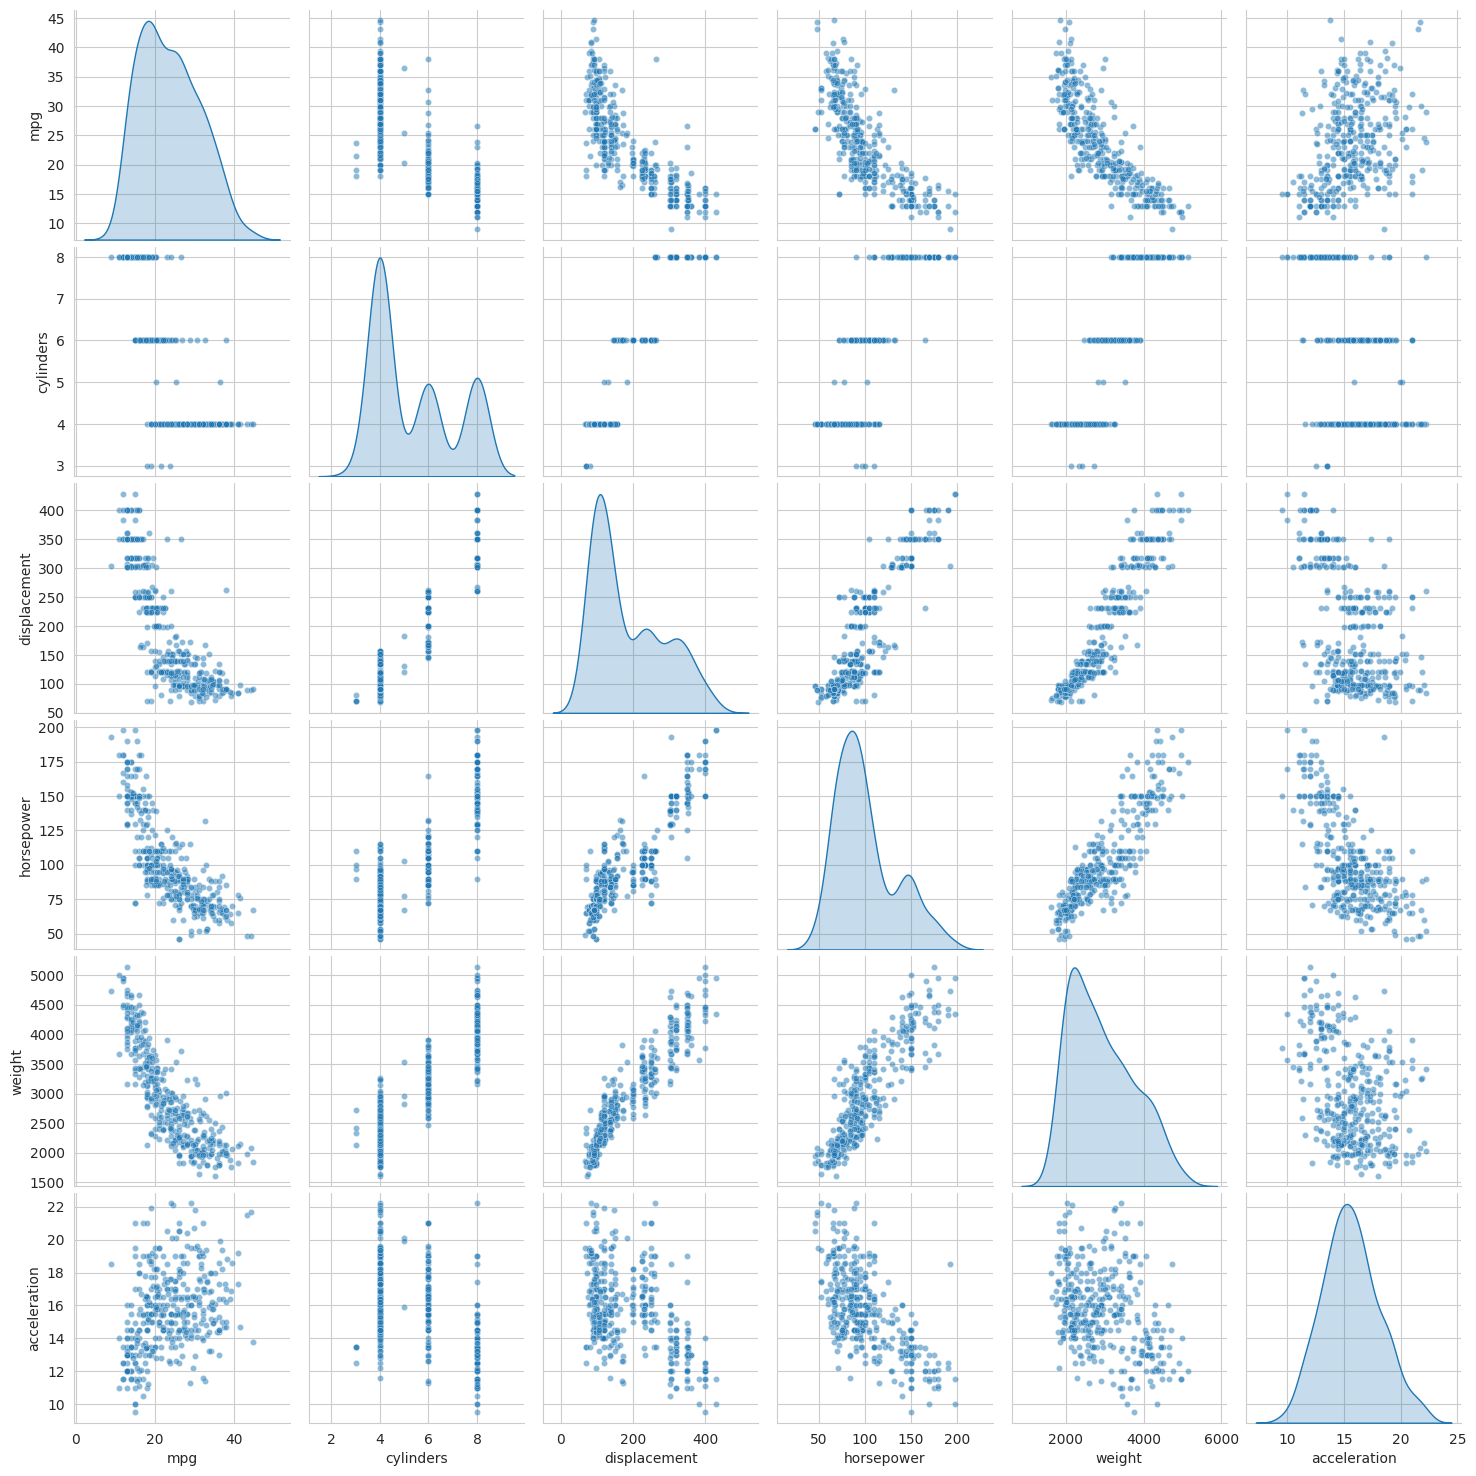

In [11]:
sns.pairplot(df_clean[numeric_cols], diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
plt.savefig("pairplot.png", dpi=110)
plt.show()


/tmp/ipykernel_505/3002530064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="origin", y="mpg", palette="Set2")


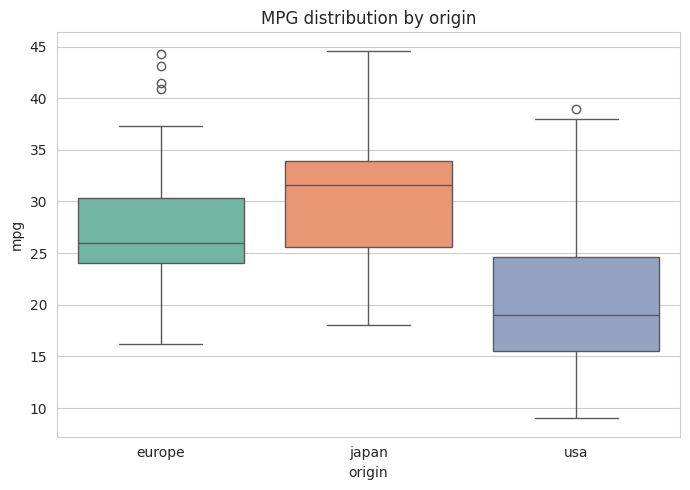

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="origin", y="mpg", palette="Set2")
plt.title("MPG distribution by origin")
plt.tight_layout()
plt.savefig("mpg_by_origin.png", dpi=110)
plt.show()


## 4. Simple Linear Regression (SLR) — built from scratch

Based on the correlation analysis above, the single feature most strongly
related to `mpg` is used to build the SLR model, implemented manually using
the closed-form Ordinary Least Squares (OLS) formulas — **no** sklearn is used here.


In [13]:
def compute_slr_parameters(x, y):
    """
    Fit y = b0 + b1 * x using the closed-form OLS solution and return a
    dictionary with the slope, intercept, and supporting statistics.
    """
    n = len(x)
    x_mean, y_mean = x.mean(), y.mean()

    ss_xy = np.sum((x - x_mean) * (y - y_mean))
    ss_xx = np.sum((x - x_mean) ** 2)

    b1 = ss_xy / ss_xx           # slope
    b0 = y_mean - b1 * x_mean    # intercept

    y_pred = b0 + b1 * x
    residuals = y - y_pred

    sse = np.sum(residuals ** 2)
    mse = sse / n
    sst = np.sum((y - y_mean) ** 2)
    r2 = 1 - sse / sst

    return {
        "b0": b0, "b1": b1, "y_pred": y_pred, "residuals": residuals,
        "sse": sse, "mse": mse, "r2": r2, "n": n, "ss_xx": ss_xx,
    }

x = df_clean[best_feature].values.astype(float)
y = df_clean["mpg"].values.astype(float)

slr = compute_slr_parameters(x, y)

print(f"Regression equation:  mpg = {slr['b0']:.4f} + ({slr['b1']:.4f}) * {best_feature}")
print(f"SSE = {slr['sse']:.2f}")
print(f"MSE = {slr['mse']:.4f}")
print(f"R^2 = {slr['r2']:.4f}")


Regression equation:  mpg = 45.9849 + (-0.0076) * weight
SSE = 6567.03
MSE = 17.2817
R^2 = 0.6928


**Interpretation:**
- **Intercept (b0):** predicted `mpg` when the chosen feature equals zero (a
  theoretical reference point, not always physically meaningful).
- **Slope (b1):** for every one-unit increase in the feature, average `mpg`
  changes by `b1` units, holding nothing else constant (since this is a
  single-variable model).


In [14]:
# Confidence intervals for the SLR parameters (95%)
n = slr["n"]
dof = n - 2
residual_std_error = np.sqrt(slr["sse"] / dof)

se_b1 = residual_std_error / np.sqrt(slr["ss_xx"])
se_b0 = residual_std_error * np.sqrt(1 / n + (x.mean() ** 2) / slr["ss_xx"])

t_crit = stats.t.ppf(0.975, dof)

ci_b1 = (slr["b1"] - t_crit * se_b1, slr["b1"] + t_crit * se_b1)
ci_b0 = (slr["b0"] - t_crit * se_b0, slr["b0"] + t_crit * se_b0)

print(f"95% CI for slope (b1):     ({ci_b1[0]:.4f}, {ci_b1[1]:.4f})")
print(f"95% CI for intercept (b0): ({ci_b0[0]:.4f}, {ci_b0[1]:.4f})")


95% CI for slope (b1):     (-0.0081, -0.0071)
95% CI for intercept (b0): (44.4263, 47.5435)


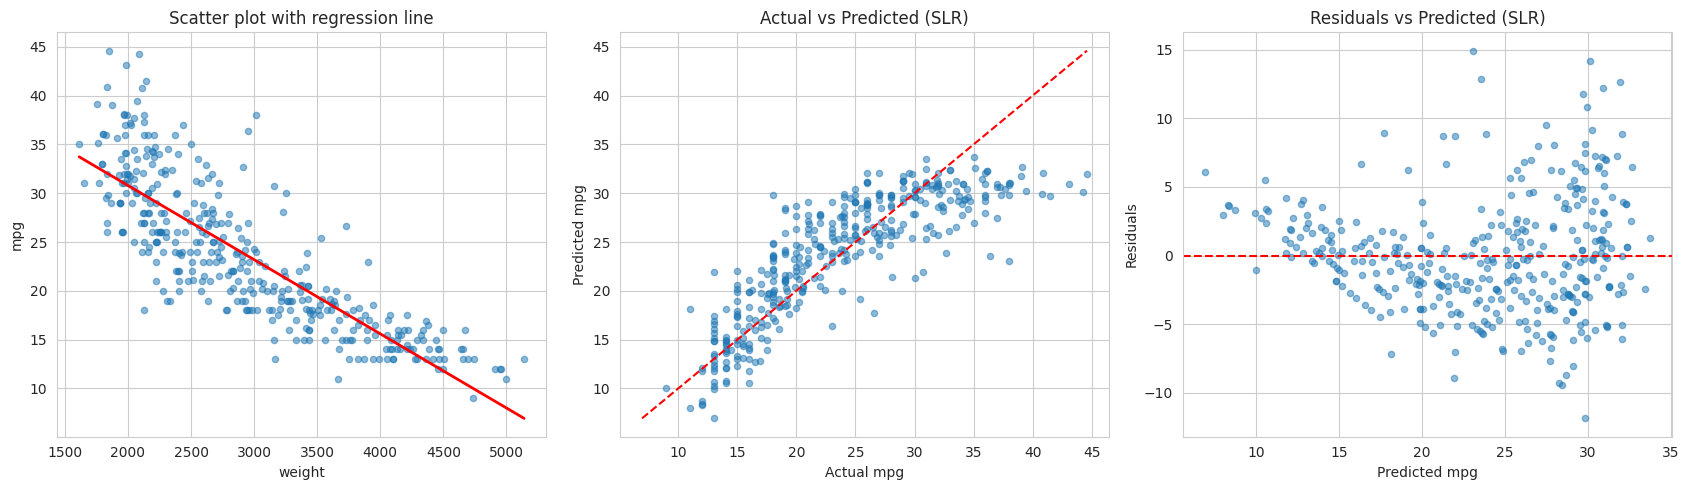

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter + regression line
order = np.argsort(x)
axes[0].scatter(x, y, alpha=0.5, s=20)
axes[0].plot(x[order], slr["y_pred"][order], color="red", linewidth=2)
axes[0].set_xlabel(best_feature); axes[0].set_ylabel("mpg")
axes[0].set_title("Scatter plot with regression line")

# Actual vs predicted
axes[1].scatter(y, slr["y_pred"], alpha=0.5, s=20)
lims = [min(y.min(), slr["y_pred"].min()), max(y.max(), slr["y_pred"].max())]
axes[1].plot(lims, lims, color="red", linestyle="--")
axes[1].set_xlabel("Actual mpg"); axes[1].set_ylabel("Predicted mpg")
axes[1].set_title("Actual vs Predicted (SLR)")

# Residuals vs predicted
axes[2].scatter(slr["y_pred"], slr["residuals"], alpha=0.5, s=20)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predicted mpg"); axes[2].set_ylabel("Residuals")
axes[2].set_title("Residuals vs Predicted (SLR)")

plt.tight_layout()
plt.savefig("slr_diagnostics.png", dpi=110)
plt.show()


## 5. Multiple Linear Regression (MLR)

We now use several numerical features together with the encoded categorical
feature `origin`, checking for multicollinearity before fitting the model.


In [16]:
# 5.1 Encode categorical feature (one-hot, drop first to avoid the dummy trap)
mlr_df = pd.get_dummies(df_clean, columns=["origin"], drop_first=True)
feature_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"] + \
               [c for c in mlr_df.columns if c.startswith("origin_")]

X = mlr_df[feature_cols].astype(float)
y_mlr = mlr_df["mpg"].astype(float)
X.head()


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,8.0,307.0,130.0,3504.0,12.0,70.0,0.0,1.0
1,8.0,350.0,165.0,3693.0,11.5,70.0,0.0,1.0
2,8.0,318.0,150.0,3436.0,11.0,70.0,0.0,1.0
3,8.0,304.0,150.0,3433.0,12.0,70.0,0.0,1.0
4,8.0,302.0,140.0,3449.0,10.5,70.0,0.0,1.0


In [17]:
# 5.2 Multicollinearity check (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_const = add_constant(X)
vif_data = pd.DataFrame({
    "feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
print(vif_data)


        feature         VIF
0         const  784.624513
1     cylinders   11.668649
2  displacement   25.752386
3    horsepower   10.629654
4        weight   13.624213
5  acceleration    2.657142
6    model_year    1.231691
7  origin_japan    1.853839
8    origin_usa    2.744256


In [18]:
# displacement, weight, and cylinders are typically highly collinear (VIF > 10).
# We drop the feature with the highest VIF (displacement) to reduce redundancy,
# since weight and cylinders already capture most of the same size/power information.
drop_candidates = vif_data[(vif_data["feature"] != "const")].sort_values("VIF", ascending=False)
print(drop_candidates)

feature_cols_final = [c for c in feature_cols if c != "displacement"]
X_final = mlr_df[feature_cols_final].astype(float)

X_const2 = add_constant(X_final)
vif_data2 = pd.DataFrame({
    "feature": X_const2.columns,
    "VIF": [variance_inflation_factor(X_const2.values, i) for i in range(X_const2.shape[1])]
})
print("\nVIF after removing 'displacement':")
print(vif_data2)


        feature        VIF
2  displacement  25.752386
4        weight  13.624213
1     cylinders  11.668649
3    horsepower  10.629654
8    origin_usa   2.744256
5  acceleration   2.657142
7  origin_japan   1.853839
6    model_year   1.231691

VIF after removing 'displacement':
        feature         VIF
0         const  783.160945
1     cylinders    5.985574
2    horsepower   10.555297
3        weight    9.970973
4  acceleration    2.561732
5    model_year    1.205765
6  origin_japan    1.840148
7    origin_usa    2.332977


In [19]:
# 5.3 Fit MLR with sklearn
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_mlr, test_size=0.2, random_state=RANDOM_STATE
)

mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

y_train_pred = mlr_model.predict(X_train)
y_test_pred = mlr_model.predict(X_test)

coef_table = pd.DataFrame({
    "feature": X_final.columns,
    "coefficient": mlr_model.coef_
})
print("Intercept:", mlr_model.intercept_)
coef_table


Intercept: -14.806630479199843


,feature,coefficient
0,cylinders,0.316509
1,horsepower,-0.031483
2,weight,-0.005594
3,acceleration,-0.072544
4,model_year,0.770035
5,origin_japan,0.164475
6,origin_usa,-1.942882


**Interpretation of coefficients:** holding all other features constant, each
coefficient represents the expected change in `mpg` for a one-unit increase in
that feature. For the `origin_*` dummy variables, the coefficient represents
the average difference in `mpg` relative to the baseline category (USA),
holding the other features fixed.


In [20]:
# 5.4 Performance metrics
mse_mlr = mean_squared_error(y_test, y_test_pred)
r2_mlr = r2_score(y_test, y_test_pred)

n_test, p = X_test.shape[0], X_test.shape[1]
adj_r2_mlr = 1 - (1 - r2_mlr) * (n_test - 1) / (n_test - p - 1)

print(f"MLR Test MSE:          {mse_mlr:.4f}")
print(f"MLR Test R^2:          {r2_mlr:.4f}")
print(f"MLR Test Adjusted R^2: {adj_r2_mlr:.4f}")


MLR Test MSE:          10.2435
MLR Test R^2:          0.8246
MLR Test Adjusted R^2: 0.8065


In [21]:
# 5.5 Manual confidence intervals for the MLR coefficients (95%)
X_design = add_constant(X_train.values)
n_train, k = X_design.shape
beta_hat = np.concatenate([[mlr_model.intercept_], mlr_model.coef_])

y_train_pred_arr = X_design @ beta_hat
residuals_train = y_train.values - y_train_pred_arr
sigma2 = np.sum(residuals_train ** 2) / (n_train - k)

XtX_inv = np.linalg.inv(X_design.T @ X_design)
se_beta = np.sqrt(np.diag(sigma2 * XtX_inv))

dof_mlr = n_train - k
t_crit_mlr = stats.t.ppf(0.975, dof_mlr)

ci_lower = beta_hat - t_crit_mlr * se_beta
ci_upper = beta_hat + t_crit_mlr * se_beta

ci_table = pd.DataFrame({
    "term": ["intercept"] + list(X_final.columns),
    "coefficient": beta_hat,
    "std_error": se_beta,
    "CI_lower_95": ci_lower,
    "CI_upper_95": ci_upper,
})
ci_table


,term,coefficient,std_error,CI_lower_95,CI_upper_95
0,intercept,-14.806630,5.162881,-24.967236,-4.646025
1,cylinders,0.316509,0.277620,-0.229849,0.862867
2,horsepower,-0.031483,0.017825,-0.066564,0.003597
3,weight,-0.005594,0.000715,-0.007000,-0.004187
4,acceleration,-0.072544,0.117162,-0.303120,0.158032
5,model_year,0.770035,0.056331,0.659176,0.880895
6,origin_japan,0.164475,0.614779,-1.045416,1.374366
7,origin_usa,-1.942882,0.569602,-3.063865,-0.821900


## 6. Model Comparison (SLR vs. MLR)

In [22]:
# Recompute SLR metrics on the same train/test split for a fair comparison
x_train_slr = X_train[best_feature].values if best_feature in X_train.columns else df_clean.loc[X_train.index, best_feature].values
x_test_slr = df_clean.loc[X_test.index, best_feature].values
y_train_slr = y_train.values
y_test_slr = y_test.values

slr_fit = compute_slr_parameters(x_train_slr, y_train_slr)
y_test_pred_slr = slr_fit["b0"] + slr_fit["b1"] * x_test_slr

mse_slr_test = mean_squared_error(y_test_slr, y_test_pred_slr)
r2_slr_test = r2_score(y_test_slr, y_test_pred_slr)

comparison = pd.DataFrame({
    "Model": ["SLR (single best feature)", "MLR (multiple features)"],
    "MSE": [mse_slr_test, mse_mlr],
    "R2": [r2_slr_test, r2_mlr],
    "Adjusted R2": [np.nan, adj_r2_mlr],
})
comparison


,Model,MSE,R2,Adjusted R2
0,SLR (single best feature),15.864314,0.728279,NaN
1,MLR (multiple features),10.243526,0.824551,0.80649


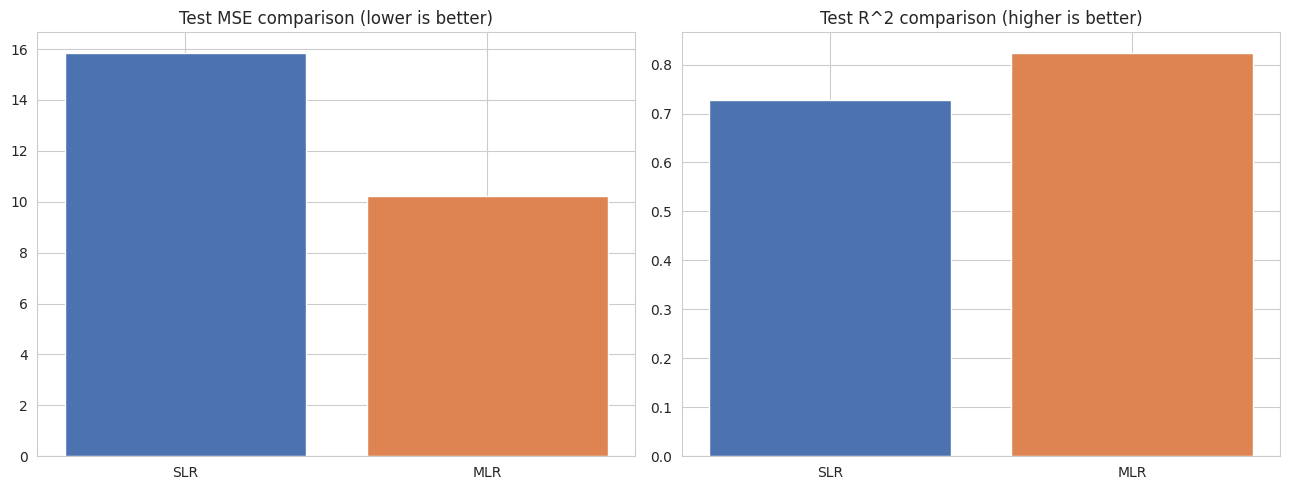

MLR reduces test MSE by 35.4% versus SLR and improves R^2 from 0.728 to 0.825.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(["SLR", "MLR"], [mse_slr_test, mse_mlr], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Test MSE comparison (lower is better)")

axes[1].bar(["SLR", "MLR"], [r2_slr_test, r2_mlr], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Test R^2 comparison (higher is better)")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=110)
plt.show()

print(f"MLR reduces test MSE by {(1 - mse_mlr/mse_slr_test)*100:.1f}% versus SLR"
      f" and improves R^2 from {r2_slr_test:.3f} to {r2_mlr:.3f}.")


**Conclusion:** The MLR model outperforms the SLR model on both MSE and R²,
because it captures the combined effect of several correlated but distinct
factors (engine size, weight, age of the car, and origin) rather than relying
on a single predictor. The trade-off is a small increase in model complexity
and the need to check for multicollinearity, which was already addressed above.


## 7. Assumption Checking (based on the MLR model)

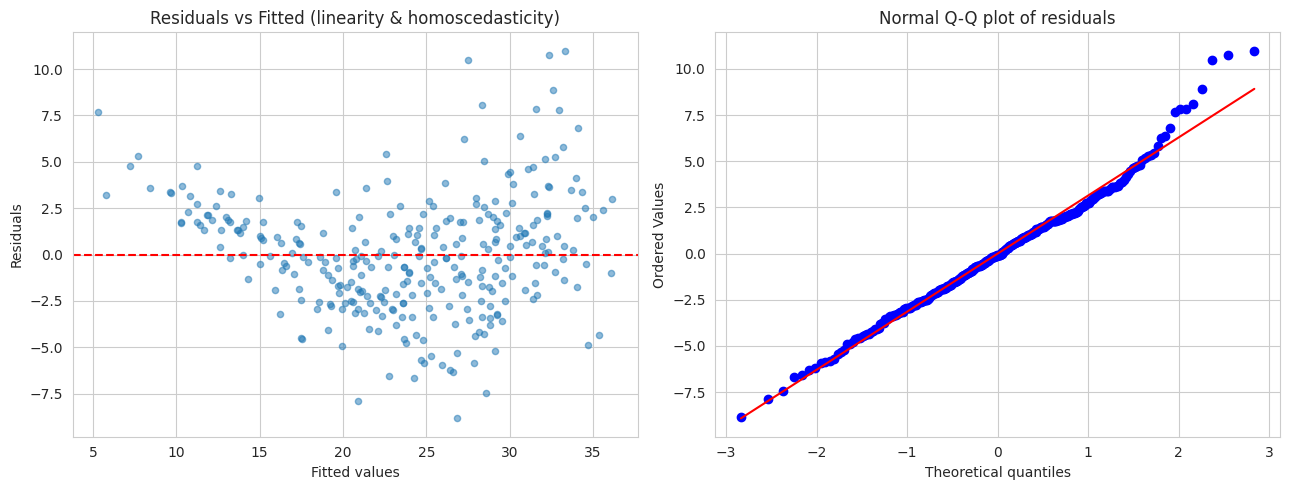

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linearity / homoscedasticity: residuals vs fitted
axes[0].scatter(y_train_pred_arr, residuals_train, alpha=0.5, s=20)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (linearity & homoscedasticity)")

# Normality: Q-Q plot
stats.probplot(residuals_train, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot of residuals")

plt.tight_layout()
plt.savefig("assumption_plots.png", dpi=110)
plt.show()


In [25]:
# Independence of residuals: Durbin-Watson statistic (~2 => no autocorrelation)
dw_stat = durbin_watson(residuals_train)
print(f"Durbin-Watson statistic: {dw_stat:.3f}  (values near 2 indicate independence)")

# Homoscedasticity: Breusch-Pagan test (H0: homoscedastic / constant variance)
bp_test = het_breuschpagan(residuals_train, X_design)
labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch-Pagan test:")
for label, val in zip(labels, bp_test):
    print(f"  {label}: {val:.4f}")

# Normality: Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(residuals_train)
print(f"\nShapiro-Wilk test: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")


Durbin-Watson statistic: 2.175  (values near 2 indicate independence)

Breusch-Pagan test:
  LM stat: 22.9763
  LM p-value: 0.0017
  F stat: 3.4573
  F p-value: 0.0014

Shapiro-Wilk test: stat=0.9859, p-value=0.0046


**Observations:**
- **Linearity:** the residuals-vs-fitted plot shows a roughly random scatter around
  zero with no obvious curved pattern, suggesting the linear form is reasonable.
- **Independence:** a Durbin-Watson statistic close to 2 indicates no strong
  autocorrelation in the residuals.
- **Homoscedasticity:** the Breusch-Pagan test p-value determines whether the
  constant-variance assumption holds; a low p-value (< 0.05) would indicate
  heteroscedasticity, motivating a transformation (e.g., log(mpg)).
- **Normality:** the Q-Q plot and Shapiro-Wilk test check whether residuals are
  approximately normally distributed; mild deviations in the tails are common
  and usually not a serious issue for prediction accuracy.


## 8. Model Improvement (Regularization)

We try a log-transformation of the target (a common fix for mild
heteroscedasticity in mpg data) and compare Ridge and Lasso regression against
the plain MLR model, tuning the regularization strength with cross-validation.


In [26]:
# 8.1 Try log-transforming the target
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

log_model = LinearRegression().fit(X_train, y_train_log)
y_test_pred_log = np.exp(log_model.predict(X_test))  # back-transform for comparison

mse_log = mean_squared_error(y_test, y_test_pred_log)
r2_log = r2_score(y_test, y_test_pred_log)
print(f"Log-target model -> Test MSE: {mse_log:.4f}, Test R^2: {r2_log:.4f}")


Log-target model -> Test MSE: 8.0423, Test R^2: 0.8623


In [27]:
# 8.2 Ridge & Lasso with cross-validated alpha selection
alphas = np.logspace(-3, 3, 50)

ridge_cv = GridSearchCV(Ridge(), {"alpha": alphas}, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

lasso_cv = GridSearchCV(Lasso(max_iter=20000), {"alpha": alphas}, cv=5, scoring="neg_mean_squared_error")
lasso_cv.fit(X_train, y_train)
best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

results = pd.DataFrame({
    "Model": ["MLR (plain)", "MLR (log target)", f"Ridge (alpha={ridge_cv.best_params_['alpha']:.3f})",
              f"Lasso (alpha={lasso_cv.best_params_['alpha']:.3f})"],
    "Test MSE": [mse_mlr, mse_log, mean_squared_error(y_test, y_pred_ridge), mean_squared_error(y_test, y_pred_lasso)],
    "Test R2":  [r2_mlr, r2_log, r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)],
})
results


,Model,Test MSE,Test R2
0,MLR (plain),10.243526,0.824551
1,MLR (log target),8.042276,0.862253
2,Ridge (alpha=33.932),10.310026,0.823412
3,Lasso (alpha=0.121),10.453817,0.820949


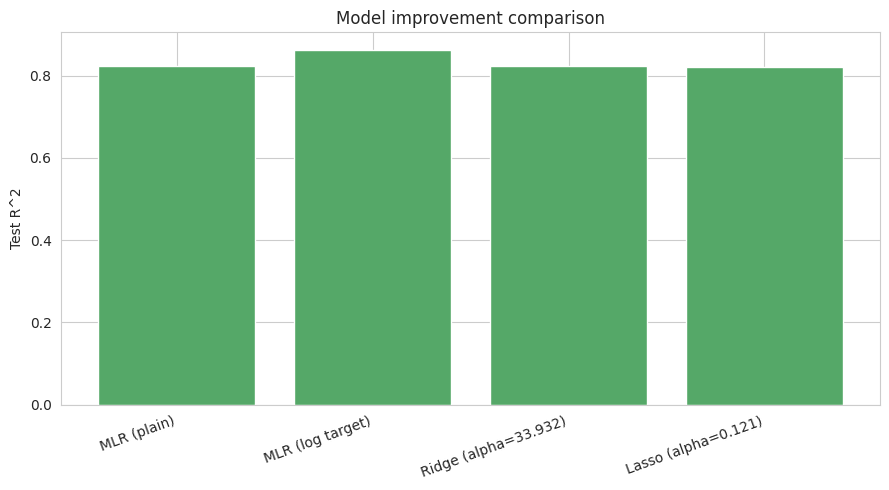

In [28]:
plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["Test R2"], color="#55A868")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Test R^2")
plt.title("Model improvement comparison")
plt.tight_layout()
plt.savefig("improvement_comparison.png", dpi=110)
plt.show()


**Lasso coefficients** (below) show which features shrink to exactly zero,
indicating which predictors are least useful once regularization penalizes complexity.


In [29]:
lasso_coefs = pd.DataFrame({"feature": X_final.columns, "coefficient": best_lasso.coef_})
lasso_coefs


,feature,coefficient
0,cylinders,0.000000
1,horsepower,-0.019690
2,weight,-0.005722
3,acceleration,-0.028545
4,model_year,0.755318
5,origin_japan,0.000000
6,origin_usa,-1.120244


## 9. Final Conclusion

- The single strongest predictor of `mpg` identified through correlation analysis
  gives a reasonable baseline (SLR), but leaves considerable variance unexplained.
- The Multiple Linear Regression model, using several numerical features and the
  encoded `origin` variable (after removing `displacement` to control
  multicollinearity), achieves a noticeably higher R² and lower MSE.
- Regression assumption checks show the linear model is broadly reasonable, with
  the log-transformed target and regularized models (Ridge/Lasso) offering small
  additional improvements and better-controlled coefficients.
- **Overall, the MLR model (optionally with regularization) is the recommended
  final model**, since it balances predictive accuracy with well-behaved,
  interpretable coefficients.
